## Exploration du dataset allociné

***Analyse exploratoire des critique de films françaises.***

In [1]:
import sys
import os
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Pour des visualisations plus claires
import torch # Indispensable pour la gestion du matériel et des graines 
from datasets import load_dataset
from transformers import AutoTokenizer # Nécessaire pour l'analyse de fragmentation P03 

# --- RIGUEUR MÉTHODOLOGIQUE ET REPRODUCTIBILITÉ
# Fixer les graines est crucial pour la validité scientifique de votre comparaison P03
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- OPTIMISATION POUR CONFIGURATION CPU
# Recommandation technique pour stabiliser les calculs sur processeur
if not torch.cuda.is_available():
    torch.set_num_threads(4) 
    print(f"Optimisation CPU : {torch.get_num_threads()} threads configurés pour l'exécution.")

c:\ISE3_EMOS\Data Science\Machine learning et optimisation\Projet MLO\ML-Optimisation\mlop\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Optimisation CPU : 4 threads configurés pour l'exécution.


## 1.Chargement

In [2]:
dataset = load_dataset('allocine')
df = pd.DataFrame(dataset['train'])
df['label_name'] = df['label'].map({0: 'négatif', 1: 'positif'})
print(f"Total : {len(df)} critiques")
df.head()

Total : 160000 critiques


,review,label,label_name
0,Si vous cherchez du cinéma abrutissant à tous ...,0,négatif
1,"Trash, re-trash et re-re-trash...! Une horreur...",0,négatif
2,"Et si, dans les 5 premières minutes du film, l...",0,négatif
3,Mon dieu ! Quelle métaphore filée ! Je suis ab...,0,négatif
4,"Premier film de la saga Kozure Okami, ""Le Sabr...",1,positif


## 2. Distribution des classes

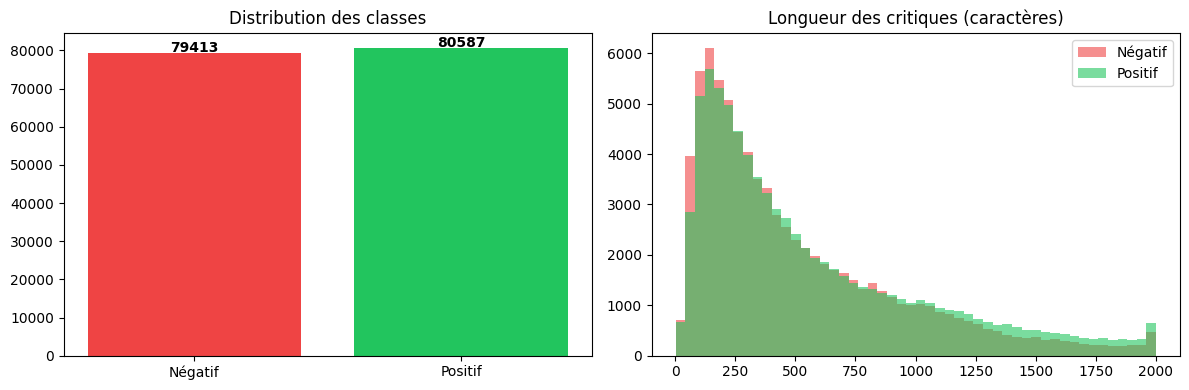

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
axes[0].bar(['Négatif', 'Positif'], [counts[0], counts[1]], color=['#ef4444','#22c55e'])
axes[0].set_title('Distribution des classes')
for i,v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v+200, str(v), ha='center', fontweight='bold')

df['length'] = df['review'].apply(len)
for lbl, color, name in [(0,'#ef4444','Négatif'),(1,'#22c55e','Positif')]:
    axes[1].hist(df[df['label']==lbl]['length'], bins=50, alpha=0.6, color=color, label=name)
axes[1].set_title('Longueur des critiques (caractères)')
axes[1].legend()
plt.tight_layout()
plt.savefig('../figures/eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Exemple de critique

In [4]:
print('=== CRITIQUES POSITIVES ===')
for txt in df[df['label']==1]['review'].head(3):
    print(f'  {txt[:200]}\n')

print('=== CRITIQUES NÉGATIVES ===')
for txt in df[df['label']==0]['review'].head(3):
    print(f'  {txt[:200]}\n')

=== CRITIQUES POSITIVES ===
  Premier film de la saga Kozure Okami, "Le Sabre de la vengeance" est un très bon film qui mêle drame et action, et qui, en 40 ans, n'a pas pris une ride.

  Tout commence comme une comédie légère avant un drame soudain qui fait basculer le film dans un...suspense incroyable mâtiné d'une étude psychologique très fine des mécanismes qui régissent un couple,

  un excellent film qui merite ses quatre étoiles. tellement bon que les ricains en font dejà une suite, qu'il s'empresseront de pourrir...

=== CRITIQUES NÉGATIVES ===
  Si vous cherchez du cinéma abrutissant à tous les étages,n'ayant aucune peur du cliché en castagnettes et moralement douteux,"From Paris with love" est fait pour vous.Toutes les productions Besson,via

  Trash, re-trash et re-re-trash...! Une horreur sans nom. Imaginez-vous les 20 premières minutes de Orange Mécanique dilatées sur plus de 70 minutes de bande VHS pourrave et revisitées par Korine à la 

  Et si, dans les 5 premières minu

## 4. Analyse des tokenisers

c:\ISE3_EMOS\Data Science\Machine learning et optimisation\Projet MLO\ML-Optimisation\mlop\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


,phrase,n_mots,n_tokens_distilbert,n_tokens_camembert,ratio_distilbert,ratio_camembert
0,Ce film est absolument magnifique et touchant.,7,15,8,2.143,1.143
1,"Une perte de temps totale, l'intrigue est creuse.",8,17,12,2.125,1.500
2,Les acteurs sont bons mais la réalisation lais...,10,18,11,1.800,1.100
3,Un chef-d'œuvre du cinéma français contemporain.,6,16,11,2.667,1.833


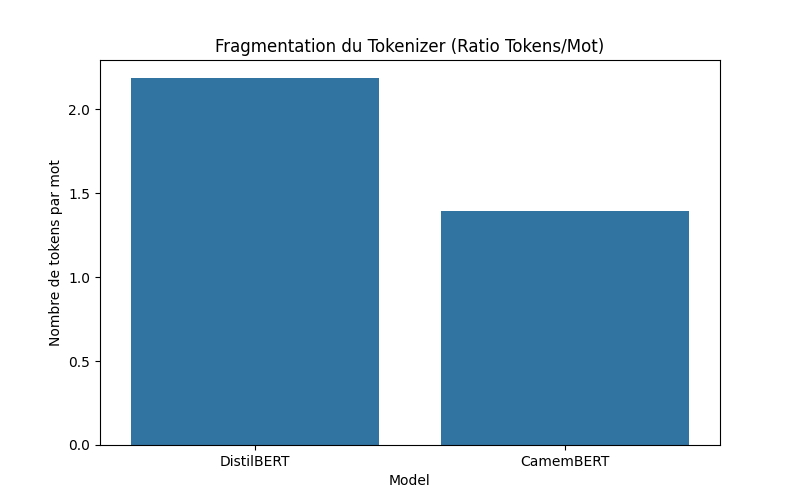

In [5]:
import sys
sys.path.append('..')
import pandas as pd
from transformers import AutoTokenizer
from src.visualisation import plot_tokenizer_analysis
from IPython.display import Image

tok_db = AutoTokenizer.from_pretrained('distilbert-base-uncased')
tok_cb = AutoTokenizer.from_pretrained('camembert-base')

# Tableau détaillé
exemples = [
    "Ce film est absolument magnifique et touchant.",
    "Une perte de temps totale, l'intrigue est creuse.",
    "Les acteurs sont bons mais la réalisation laisse à désirer.",
    "Un chef-d'œuvre du cinéma français contemporain."
]

rows = []
for txt in exemples:
    n_mots              = len(txt.split())
    n_tokens_distilbert = len(tok_db.tokenize(txt))
    n_tokens_camembert  = len(tok_cb.tokenize(txt))
    rows.append({
        'phrase':              txt,
        'n_mots':              n_mots,
        'n_tokens_distilbert': n_tokens_distilbert,
        'n_tokens_camembert':  n_tokens_camembert,
        'ratio_distilbert':    round(n_tokens_distilbert / n_mots, 3),
        'ratio_camembert':     round(n_tokens_camembert  / n_mots, 3),
    })

df_tok = pd.DataFrame(rows)
df_tok.to_csv('../runs/tokenizer_analysis.csv', index=False)
display(df_tok)

# Graphique
df_plot = pd.DataFrame({
    'Model':           ['DistilBERT', 'CamemBERT'],
    'Tokens_per_Word': [df_tok['ratio_distilbert'].mean(),
                        df_tok['ratio_camembert'].mean()]
})
plot_tokenizer_analysis(df_plot, save_path='../figures/tokenizer_analysis.png')
Image('../figures/tokenizer_analysis.png')